# Naive Bayes - Gaussiano

In [15]:
from sklearn.datasets import load_breast_cancer, fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


In [16]:
datos = load_breast_cancer()

X = datos.data
y = datos.target

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=23)

In [18]:
modelo = GaussianNB()

modelo.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [19]:
y_pred = modelo.predict(X_test)

In [20]:
print("Accuracy NB Gaussiano",
    accuracy_score(
        y_test,
        y_pred
    )
)

Accuracy NB Gaussiano 0.956140350877193


# TODO: IMPLEMENTAR DEMÁS METRICAS DE EVALUACIÓN MÁS MATRIZ DE CONFUSIÓN - REALIZAR GRÁFICOS PARA VISUALIZAR MÉTRICAS


Accuracy NB Gaussiano: 0.956140350877193
Precision NB Gaussiano: 0.9487179487179487
Recall NB Gaussiano: 0.9866666666666667
F1-score NB Gaussiano: 0.9673202614379085

Reporte de clasificación NB Gaussiano:

              precision    recall  f1-score   support

   malignant       0.97      0.90      0.93        39
      benign       0.95      0.99      0.97        75

    accuracy                           0.96       114
   macro avg       0.96      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



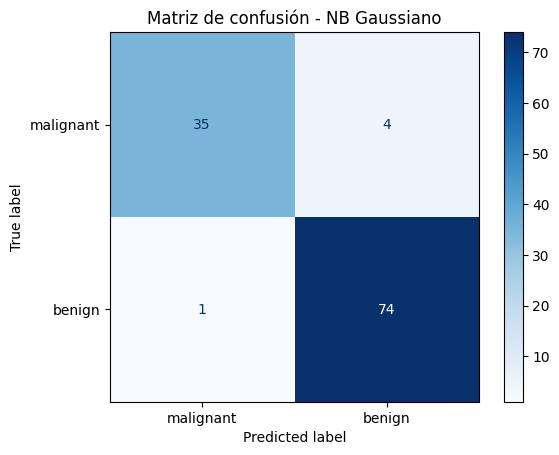

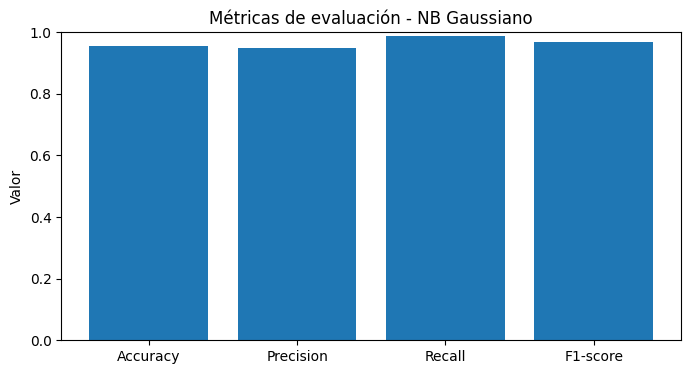

In [21]:
# Métricas de evaluación para el modelo NB Gaussiano
precision_nb = precision_score(y_test, y_pred)
recall_nb = recall_score(y_test, y_pred)
f1_nb = f1_score(y_test, y_pred)
cm_nb = confusion_matrix(y_test, y_pred)

print("Accuracy NB Gaussiano:", accuracy_score(y_test, y_pred))
print("Precision NB Gaussiano:", precision_nb)
print("Recall NB Gaussiano:", recall_nb)
print("F1-score NB Gaussiano:", f1_nb)
print("\nReporte de clasificación NB Gaussiano:\n")
print(classification_report(y_test, y_pred, target_names=datos.target_names))

# Matriz de confusión
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=datos.target_names)
disp_nb.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión - NB Gaussiano")
plt.show()

# Gráfico de métricas
metricas_nb = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_nb,
    "Recall": recall_nb,
    "F1-score": f1_nb
}

plt.figure(figsize=(8, 4))
plt.bar(metricas_nb.keys(), metricas_nb.values())
plt.ylim(0, 1)
plt.title("Métricas de evaluación - NB Gaussiano")
plt.ylabel("Valor")
plt.show()


In [22]:
categorias = [
    'sci.space',
    'rec.sport.baseball'
]

In [23]:
datosm = fetch_20newsgroups(
    subset= 'train',
    categories= categorias
)

In [24]:
vectores = CountVectorizer() # agregar parámetro binary = True

Xm = vectores.fit_transform(datosm.data)
ym = datosm.target

In [25]:
X_trainm, X_testm, y_trainm, y_testm = train_test_split(Xm, ym, test_size= 0.3, random_state=30)

In [26]:
modeloM = MultinomialNB()

modeloM.fit(X_trainm, y_trainm)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [27]:
y_predM = modeloM.predict(X_testm)

# TODO: IMPLEMENTAR DEMÁS METRICAS DE EVALUACIÓN MÁS MATRIZ DE CONFUSIÓN - REALIZAR GRÁFICOS PARA VISUALIZAR MÉTRICAS

Accuracy NB Multinomial: 0.9915966386554622
Precision NB Multinomial: 0.9940119760479041
Recall NB Multinomial: 0.9880952380952381
F1-score NB Multinomial: 0.991044776119403

Reporte de clasificación NB Multinomial:

                    precision    recall  f1-score   support

rec.sport.baseball       0.99      0.99      0.99       189
         sci.space       0.99      0.99      0.99       168

          accuracy                           0.99       357
         macro avg       0.99      0.99      0.99       357
      weighted avg       0.99      0.99      0.99       357



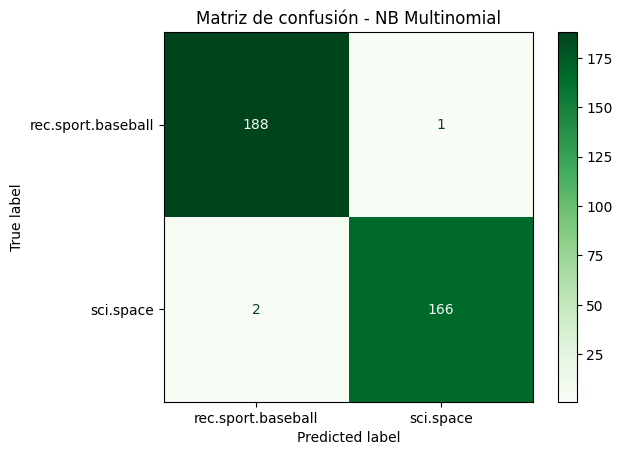

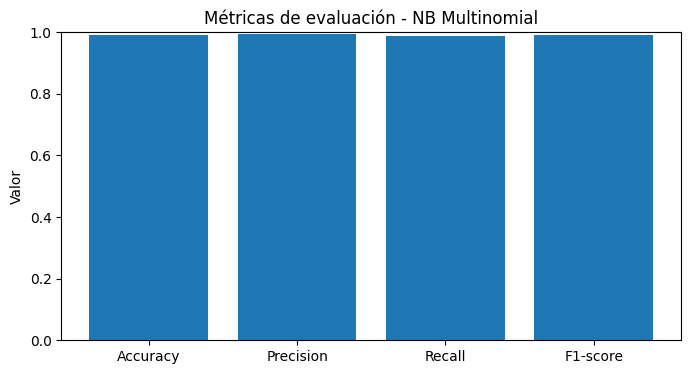

In [28]:
# Métricas de evaluación para el modelo NB Multinomial
precision_m = precision_score(y_testm, y_predM)
recall_m = recall_score(y_testm, y_predM)
f1_m = f1_score(y_testm, y_predM)
cm_m = confusion_matrix(y_testm, y_predM)

print("Accuracy NB Multinomial:", accuracy_score(y_testm, y_predM))
print("Precision NB Multinomial:", precision_m)
print("Recall NB Multinomial:", recall_m)
print("F1-score NB Multinomial:", f1_m)
print("\nReporte de clasificación NB Multinomial:\n")
print(classification_report(y_testm, y_predM, target_names=datosm.target_names))

# Matriz de confusión
disp_m = ConfusionMatrixDisplay(confusion_matrix=cm_m, display_labels=datosm.target_names)
disp_m.plot(cmap="Greens", values_format="d")
plt.title("Matriz de confusión - NB Multinomial")
plt.show()

# Gráfico de métricas
metricas_m = {
    "Accuracy": accuracy_score(y_testm, y_predM),
    "Precision": precision_m,
    "Recall": recall_m,
    "F1-score": f1_m
}

plt.figure(figsize=(8, 4))
plt.bar(metricas_m.keys(), metricas_m.values())
plt.ylim(0, 1)
plt.title("Métricas de evaluación - NB Multinomial")
plt.ylabel("Valor")
plt.show()
